<a href="https://colab.research.google.com/github/Sahro2266/Classification-of-Iris-data/blob/main/Classification_of_Iris_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Learning Practice 3: Traditional Classification Methods

Use this notebook as the starting point for Learning Practice 2 activities.

## Prep 1: Make you own copy of this notebook

Under the **File** menu select **Save a copy in Drive**. This will save your copy of the notebook to the special *Colab Notebooks* fold in your Google drive.

## Prep 2: Student Name: **Sahro Elmi**

Adding your name to the notebook makes it grading easier. Please take a second an put your name in each of your notebooks.

## Prep 3: Writeup

Make a copy of the [Learning 3 Writeup](https://docs.google.com/document/d/12ndj2FWNRf-xVv2hoBTuIZccPnbhWlor0ent2ZF8TyE/edit?usp=sharing) to answer the questions posed in this notebook.

You will submit a link to the Writeup to Brightspace late.

### My Writeup Link:

https://docs.google.com/document/d/1ONQwAazwQa2InXkTdcer6fVWaZtocgBzacfxOY9_nzA/edit?tab=t.0

## Prep #4: Video

Watch the [Learning Practice 4 Walkthrough video]https://www.youtube.com/watch?v=8MfDdwiWuco)



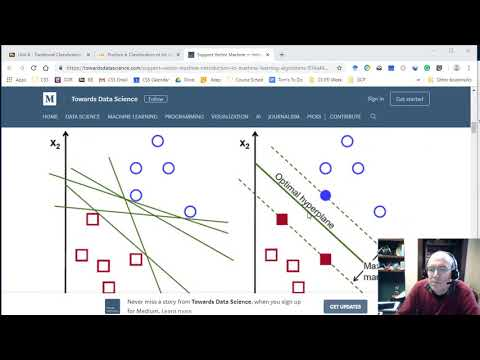

In [ ]:
# Display video link below
from IPython.lib.display import YouTubeVideo
YouTubeVideo('8MfDdwiWuco')

# Classifiers
We will try out a couple  traditional classifiers and compare them.

We will focus on
- K-Nearest Neighbors or from sklearn.neighbors import KNeighborsClassifier
- Support Vector Machines (SVM) or from sklearn.svm import SVC
- Decision Trees or from sklearn.tree import DecisionTreeClassifier
  
For a good comparison of classifiers see [SckKitLearn's Classifier Comparison]( http://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py)
  
Note, in the next unit we will revisit these adding deminsional reduction methods like PCA or LDA
    

## Revisit the Iris classification problem

*Note: This description comes from [Google's Custom Training Walkthroughs](https://www.tensorflow.org/tutorials/eager/custom_training_walkthrough).*

Imagine you are a botanist seeking an automated way to categorize each Iris flower you find. Machine learning provides many algorithms to classify flowers statistically. For instance, a sophisticated machine learning program could classify flowers based on photographs. Our ambitions are more modest—we're going to classify Iris flowers based on the length and width measurements of their [sepals](https://en.wikipedia.org/wiki/Sepal) and [petals](https://en.wikipedia.org/wiki/Petal).

The Iris genus entails about 300 species, but our program will only classify the following three:

* Iris setosa
* Iris virginica
* Iris versicolor

<table>
  <tr><td>
    <img src="https://www.tensorflow.org/images/iris_three_species.jpg"
         alt="Petal geometry compared for three iris species: Iris setosa, Iris virginica, and Iris versicolor">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://commons.wikimedia.org/w/index.php?curid=170298">Iris setosa</a> (by <a href="https://commons.wikimedia.org/wiki/User:Radomil">Radomil</a>, CC BY-SA 3.0), <a href="https://commons.wikimedia.org/w/index.php?curid=248095">Iris versicolor</a>, (by <a href="https://commons.wikimedia.org/wiki/User:Dlanglois">Dlanglois</a>, CC BY-SA 3.0), and <a href="https://www.flickr.com/photos/33397993@N05/3352169862">Iris virginica</a> (by <a href="https://www.flickr.com/photos/33397993@N05">Frank Mayfield</a>, CC BY-SA 2.0).<br/>&nbsp;
  </td></tr>
</table>

Fortunately, someone has already created a [data set of 120 Iris flowers](https://en.wikipedia.org/wiki/Iris_flower_data_set) with the sepal and petal measurements. This is a classic dataset that is popular for beginner machine learning classification problems.



# Section 0: Set up libraries and training data
=== *You must run this section to set up things for any of the sections below * ===


## Setting up Python tools

We'll use three libraries for this tutorial:
- [pandas](http://pandas.pydata.org/) : dataframes for spreadsheet-like data analysis, reading CSV files, time series
- [numpy](http://www.numpy.org/) : for multidimensional data and linear algebra tools
- [matplotlib](http://matplotlib.org/) : Simple plotting and graphing
- [seaborn](http://stanford.edu/~mwaskom/software/seaborn/) : more advanced graphing




In [ ]:
# First, we'll import pandas and numpy, two data processing libraries
import pandas as pd
import numpy as np

# We'll also import seaborn and matplot, twp Python graphing libraries
import seaborn as sns
import matplotlib.pyplot as plt
#sns.set(style="white", color_codes=True)

# We will start using the sklearn machine learning library
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler

print ("Libraries Imported")

Libraries Imported


## Read in the Iris flower data
The Iris flower data is read in from a file stored on the internet.
<p>
It is stored in a Pandas DataFrame which is similar to an internal spreadsheet in that the data is stored in rows and columns.

In [ ]:
# Read in the data file from stored in a raw file in GitHub
url = 'https://raw.githubusercontent.com/CIS3115-Machine-Learning-Scholastica/CIS3115ML-Units3and4/master/Iris.csv'
iris = pd.read_csv(url)
# Set the Id column as the index since it is unique for each flower
iris.set_index('Id', inplace=True)

In [ ]:
# Display the first 5 flowers to make sure the data was read in
iris.head(5)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


## Standard Variable Names: X and y

When we use machine learning models, we will generally use these variables
- X will be the input data, in this case the size of the flower's sepal and petals
- y will be the output data or what we want to predict, in this case the species of iris

One way to this of this, is that on the graphs above the x-axis is the house size and the y-axis is the price.

## Break up data parts for training and testing

We will also break up the data using 80% of the flower samples for training the model and keeping 20% for testing the model

- X_train : The iris sizes used for training the model
- X_test : The iris sizes used for testing the model
- y_train : The species used for training the model
- y_test : The species used for testing the model

We will only use the training data for fitting the model.


In [ ]:
# Use the first four collumn for input into the model and the final iris label as output for training
X = iris.iloc[:, 0:4]
y = iris.iloc[:, 4]

# Here is another way to select these columns using the column names
# feature_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm','PetalWidthCm']
# X = iris[feature_columns].values
# y = iris['Species'].values

from sklearn.model_selection import train_test_split
# Split the data into 80% for training and 20% for testing out the models
X_train, X_test, y_train, y_test = train_test_split(X, y.ravel(), test_size=0.2)

print ("Shape of train data: ", X_train.shape)
print ("Shape of train output: ", y_train.shape)

print ("Shape of testing data: ", X_test.shape)
print ("Shape of testing output: ", y_test.shape)

Shape of train data:  (120, 4)
Shape of train output:  (120,)
Shape of testing data:  (30, 4)
Shape of testing output:  (30,)


/tmp/ipykernel_13632/3648602541.py:12: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  X_train, X_test, y_train, y_test = train_test_split(X, y.ravel(), test_size=0.2)


In [ ]:
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Id,,,,
1,5.1,3.5,1.4,0.2
2,4.9,3.0,1.4,0.2
3,4.7,3.2,1.3,0.2
4,4.6,3.1,1.5,0.2
5,5.0,3.6,1.4,0.2
...,...,...,...,...
146,6.7,3.0,5.2,2.3
147,6.3,2.5,5.0,1.9
148,6.5,3.0,5.2,2.0


In [ ]:
y

,Species
Id,
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
5,Iris-setosa
...,...
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


#Section 1:  K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a relatively simple classification algorithm. Given a set of labeled data, when a new unknown data point needs to be classified, we find the known points that are closest to it.

Let's say we are classifying fruit as either apples or oranges. Assume we measure two parameters for each fruit.
- The smoothness as a number between 1 and 10
- Amount of red color as a number between 0 and 25

We have a set of fruit we already know are either apples or oranges. When a new fruit arrives we measure its smoothness and red color and compare these values to the known fruit as follows:
1. We use the Euclidean distance to calculate how near the new fruit is to every known fruit.
1. We find the 3 nearest known fruits. Let us assume they are an Orange, an Apple and another Apple.
1. We classify the new fruit based on what is the most common type of neighbor; in this case, it is labeled as an Apple since two of the three neighbors are apples.

In the example above we looked at the 3 nearest neighbors, but we could have just as well looked at the 5 nearest neighbors or the 10 nearest neighbors. In general, we use the term K Nearest Neighbors and assume K can be any whole number.

The KNN algorithm works well for small datasets but does not work well on large datasets since it can take a lot of time and memory to compare the new item with every known item in the data set.

For another overview see [KNN Classification using Scikit-learn](https://www.datacamp.com/community/tutorials/k-nearest-neighbor-classification-scikit-learn) by Avinash Navlani



![KNN Image]( https://raw.githubusercontent.com/CIS3115-Machine-Learning-Scholastica/CIS3115ML-Units3and4/master/K_nearest_neighbors.jpg )
  
## Question 1.1: Understanding the K in K-Nearest Neighbor
---
Answer the following questions in the [Learning 4  Writeup](https://docs.google.com/document/d/12ndj2FWNRf-xVv2hoBTuIZccPnbhWlor0ent2ZF8TyE/edit?usp=sharing)

 Using the graph above, which plots data related to Apples and Oranges, determine the following by k-nearest neighbors using either visual inspection or simple measuring:
1.	The classification of the x at  (18.8, 4.9) when k = 1:	 Looking at the 1 nearest neighbor, should the x be classified as an Apple, an Orange, or  Neither
1.	The classification of the x at  (18.8, 4.9) when k = 3: Looking at the 3 nearest neighbors, should the x be classified as an Apple, an Orange, or  Neither
1.	The classification of the x at  (18.8, 4.9) when k = 5: Looking at the 5 nearest neighbors, should the x be classified as an Apple, an Orange, or  Neither


## Question 1.2: Testing KNN with different K
The code below runs the KNN algorithm initially with 5 neighbors. Try this code out with different numbers of neighbors and record the results here in your writeup

Try to get a score as high as you can. A score of 100% or 1.0 means the algorithm is classifying the new data with 100% accuracy.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
# Set up the K-Nearest neighbor model using the k nearest neighbors. Change the value of n_neighbors
knn_model = KNeighborsClassifier(n_neighbors=100)
# Train the model on the iris data
knn_model.fit(X_train, y_train)
score = knn_model.score(X_test, y_test)
print ("The score for this model is ", score)

The score for this model is  0.26666666666666666


## Question 1.3: Prediction
Once we have trained or fit the model to the data, we can use it to make predictions.

Here we will predict the iris species for a new flower with
- SepalLengthCm = 5.2
- SepalWidthCm = 3.3
- PetalLengthCm = 1.4
- PetalWidthCm	= 0.2

This should be a Iris-setosa

Change the code below to make a prediction for a new flower with the following measurements.
- SepalLengthCm = 4.2
- SepalWidthCm = 3.0
- PetalLengthCm = 3.4
- PetalWidthCm	= 1.2

What species of Iris does our model predict for the new flower (4.2, 3.0, 3.4, 1.2)? Predicted iris species is  ['Iris-setosa']

In [ ]:
# The parameter order is SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm

prediction = knn_model.predict([[6.4, 4.3, 5.3, 3.1]])

print ("Predicted iris species is ", prediction)



Predicted iris species is  ['Iris-versicolor']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(




# Section 2: Support Vector Machine (SVM)

SVM is another algorithm for classifying data. It tries to divide the data up using lines, sometimes straight linear lines and sometimes curved lines.

SVM tries to find the best lines - actually, a plane in multiple dimensions - to divide the data up into the known categories.
## Linear SVM Classification

> The fundamental idea behind SVMs is best explained with some pictures. Figure 5-1 shows part of the iris dataset that was introduced at the end of Chapter 4. The two classes can clearly be separated easily with a straight line (they are linearly separable). The left plot shows the decision boundaries of three possible linear classifiers. The model whose decision boundary is represented by the dashed line is so bad that it does not even separate the classes properly. The other two models work perfectly on this training set, but their decision boundaries come so close to the instances that these models will probably not perform as well on new instances. In contrast, the solid line in the plot on the right represents the decision boundary of an SVM classifier; this line not only separates the two classes but also stays as far away from the closest training instances as possible. You can think of an SVM classifier as fitting the widest possible street (represented by the parallel dashed lines) between the classes. This is called large margin classification.
- From *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems*, 2nd Edition by Aurélien Géron, ISBN-13: 978-1492032649, 153-154

![alt text](https://raw.githubusercontent.com/CIS3115-Machine-Learning-Scholastica/CIS3115ML-Units3and4/master/SVM%205-1.png
 )




For a good introduction, see the first part of [Support Vector Machine — Introduction to Machine Learning Algorithms](https://towardsdatascience.com/support-vector-machine-introduction-to-machine-learning-algorithms-934a444fca47). *(I suggest you stop at the Cost Function and Gradient Updates because the math and coding get too complex for this course.)*

For a good video tutorial that explains SVM using baking cupcakes and muffins as an example is Alice Zhao's [Support Vector Machines: A Visual Explanation with Sample Python Code](https://www.youtube.com/watch?v=N1vOgolbjSc)




# Section 3: Decision Trees and Random Forests
These classification method try to break the classification task into a series of decisions structured as a tree.
> Like SVMs, Decision Trees are versatile Machine Learning algorithms that can perform both classification and regression tasks, and even multioutput tasks. They are powerful algorithms, capable of fitting complex datasets.
- From *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems*, 2nd Edition by Aurélien Géron, ISBN-13: 978-1492032649

Here is a sample from the [SKlearn documentation for decision trees](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html).
![alt text](https://scikit-learn.org/stable/_images/iris.png)

For more information on decision trees see:
*  An OK tutorial from medium.com [Decision Tree Classifier — Theory](https://medium.com/machine-learning-101/chapter-3-decision-trees-theory-e7398adac567)
* Use  https://en.wikipedia.org/wiki/Decision_tree as a reference



## Running Decision Tree model

The code below will set up a simple decision tree model and run it. In general, decision trees do not have parameters to select.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

DT_model = DecisionTreeClassifier()

# Train the model on the iris data
DT_model.fit(X_train, y_train)
score = DT_model.score(X_test, y_test)
print ("The score for this model is ", format(score, '.3f'))

The score for this model is  0.967


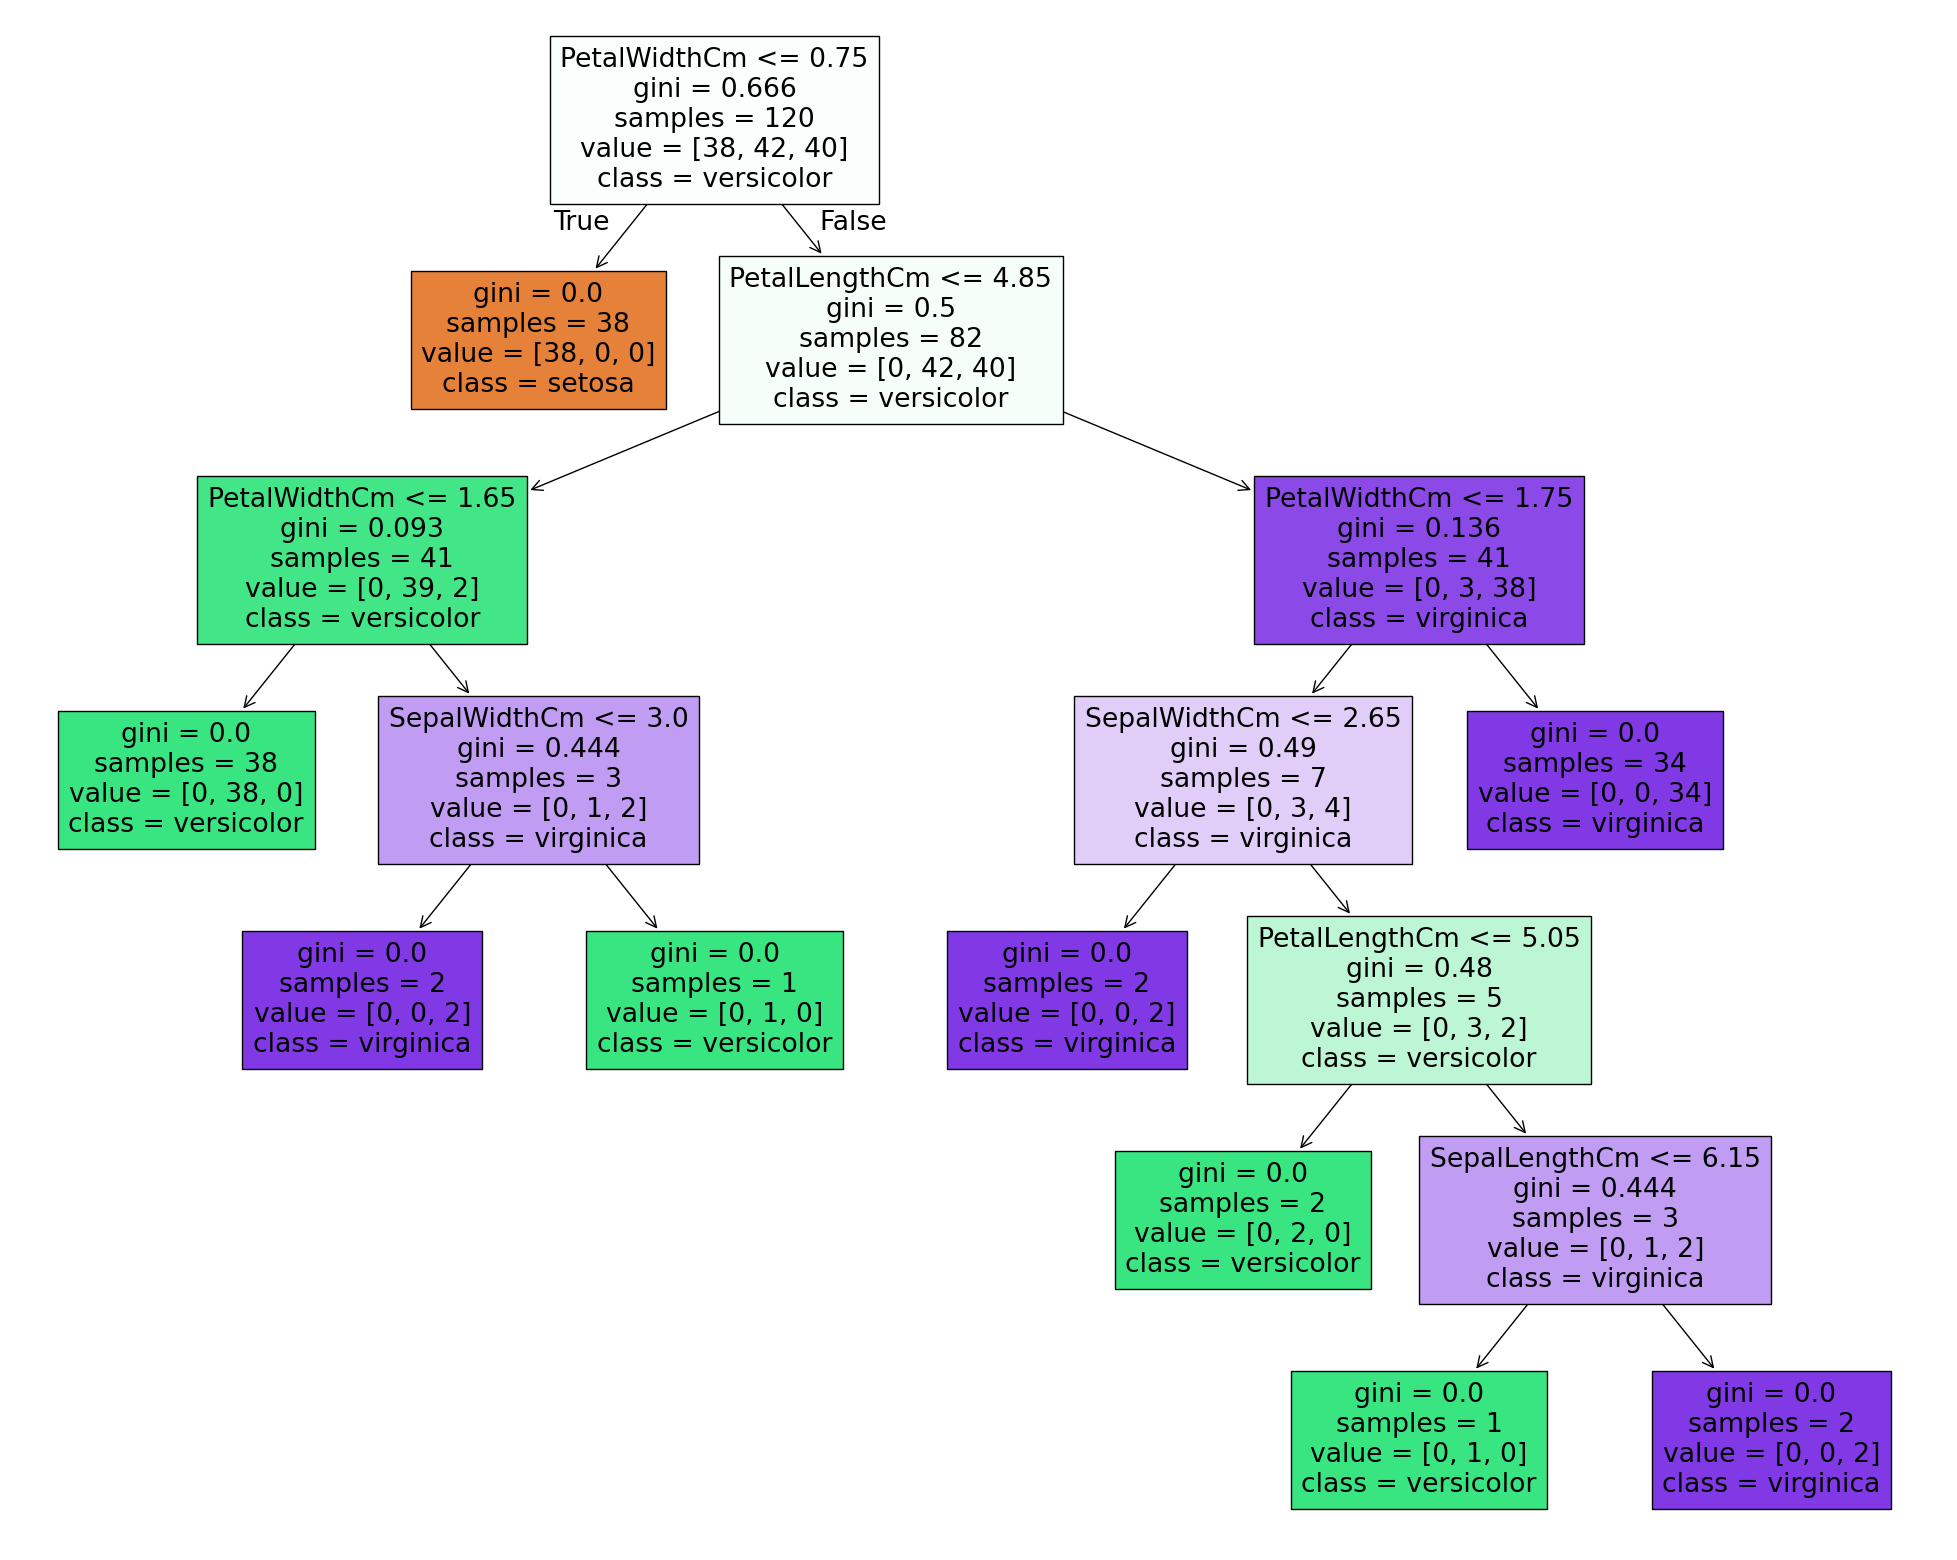

In [ ]:
from sklearn.tree import plot_tree
feature_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm','PetalWidthCm']
target_names = ['setosa', 'versicolor', 'virginica']
fig = plt.figure(figsize=(25,20))
_ = plot_tree(DT_model,
                   feature_names=feature_columns,
                   class_names=target_names,
                   filled=True)

## Random Forest
On problem with Decision Trees is that they tend to overfit the data and may not generalize well to new data samples.  A Random Forest tries to solve this be creating a number of Decision Trees, each trained on a different sub-set of the data.

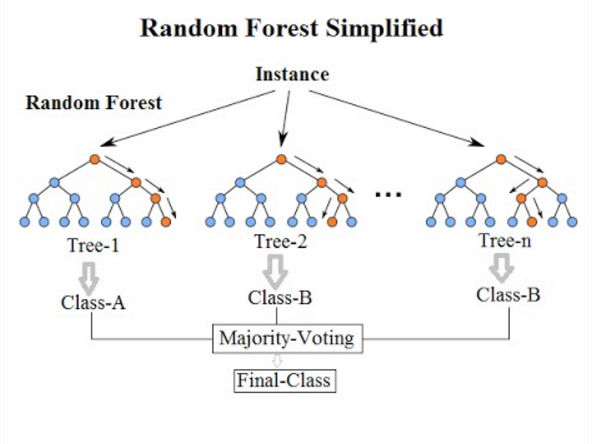

    -- Wikimedia

In [ ]:
from sklearn.ensemble import RandomForestClassifier

RF_model = RandomForestClassifier(n_estimators = 100)

# Train the model on the iris data
RF_model.fit(X_train, y_train)
score = RF_model.score(X_test, y_test)
print ("The score for this model is ", format(score, '.3f'))

The score for this model is  0.967


## Question 3.1: Decision Trees Result

How accurate was the Decision Tree model above in predicting Iris flower species?

## Question 3.2: Random Forest

Try different number of trees in the Random Forest above, change the n_estimators = 10 parameter to something between 2-100. Does your accuracy change?  

*Note, with this small of data set, a Random Forest will probably be as accurate as a Decision Tree. We will need a larger data set to see the benefits.*





# Section 4: XGBoost

Boosting is a more advanced method of combining multiple Decision Trees. XGBoost (eXtreme Gradient Boosting) is an open-source boosting library that is commonly used.

Like Random Forests, XGBoost combines a large number of Decision Trees, but does it in an advanced way, using different trees on different parts of the data set.

We won't go over the details, but it generally performs better than other methods, though it sacrafices explainability--you can not print out tree showing how decisions were made.

Note: This method can also be used for regression as well as classificaiton.
- xgb.XGBRegressor() for regression
- xgb.XGBClassifier() for classification

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

XGB_model = xgb.XGBClassifier()

# Train the model on the iris data
XGB_model.fit(X_train, y_train)
score = XGB_model.score(X_test, y_test)
print ("The score for this model is ", format(score, '.3f'))

The score for this model is  0.967


## Question 4.1: Bagging vs Boosting

Watch this short video on [Ensemble Learning - Bagging, Boosting, and Stacking explained in 4 minutes!](https://www.youtube.com/watch?v=eLt4a8-316E)

Describe what Ensemble learning is and one difference  between stacking and bagging/boosting.

# Section 5 Processing Categorical Inputs

Analyze the following sample dataset to identify the categorical fields.

## Tom's PetFinder Dataset

This is a modified version of the [PetFinder.my Adoption Prediction challenge on Kaggle](https://www.kaggle.com/c/petfinder-adoption-prediction).

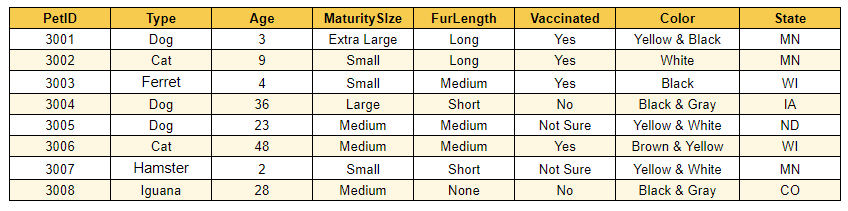

### Pet Data Fields
- PetID - Unique ID of the pet
- Type - Type of animal (Dog, Cat, Turtle, Bird, Snake, Ferret, Iguana, Hamster)
- Age - Age of pet  in months
- MaturitySize - Size at maturity (Small, Medium, Large, Extra Large)
- FurLength - Fur length (None, Short, Medium, Long)
- Vaccinated - Pet has been vaccinated (Yes, No, Not Sure)
- Color - Primary and secondary colors (Black, Brown, Golden, Yellow, Cream, Gray, White)
- State - State the pet is from (AL, AK, AZ, AR, CA, CO, CT,... WY)




### Writeup

Decide which fields are categorical. Then decide if the categorical fields are ordinal (have an implied ordering) or nominal.

Finally, decide how each categorical field should be encoded:

1.   Assign ordinal numbers
2.   Dummy variables with one-hot encoding

Fields:

- PetID - Skip this field
- Type -
- Age -
- MaturitySize -
- FurLength -
- Vaccinated -
- Color -
- State -